In [213]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings 
warnings.filterwarnings('ignore')

In [214]:
plt.style.use('seaborn-v0_8-whitegrid')

In [215]:
# Global font and figure defaults
plt.rcParams.update({
    'figure.figsize' :(13,6),
    'font.family' :'DejaVu Sans',
    'font.size'   :11,
    'axes.titlesize'  :14,
    'axes.titleweight' :'bold',
    'axes.labelsize' :11,
    'xtick.labelsize' :10,
    'ytick.labelsize': 10,
    'legend.fontsize' :10,
    'figure.dpi'  :120,
})

In [216]:
# Colour palette used across all charts for consistency
BLUE_PALETTE  = ['#1F4E79','#2E75B6','#4A90D9','#74B3CE','#A8D5F0']
MAIN_BLUE     = '#1F4E79'
ACCENT_ORANGE = '#E07B39'
SUCCESS_GREEN = '#27AE60'
DANGER_RED    = '#C0392B'


**STEP 2 — Load Cleaned Data**

In [217]:
df = pd.read_csv("cleaned_DataCoSupplyChainDataset.csv",encoding = 'latin-1')

In [218]:
print(f'Dataset loaded: {df.shape[0]:,} Rows x {df.shape[1]} Columns')

Dataset loaded: 180,519 Rows x 60 Columns


In [219]:
print(f'Data_range: {df["order_date_dateorders"].min()} to {df["order_date_dateorders"].max()}')

Data_range: 2015-01-01 00:00:00 to 2018-01-31 23:38:00


In [220]:
print(f'\nKey columns available:')
key_cols = ['sales', 'order_profit_per_order', 'profit_margin_pct',
            'is_late_delivery', 'delivery_gap_days', 'order_year',
            'order_month', 'category_name', 'shipping_mode',
            'customer_segment', 'market', 'order_size_tier']



Key columns available:


In [221]:
for col in key_cols:
    if col in df.columns:
        print(f' {col} : {df[col].dtype}')
    else:
        print(f' {col} : NOT FOUND')

 sales : float64
 order_profit_per_order : float64
 profit_margin_pct : float64
 is_late_delivery : int64
 delivery_gap_days : int64
 order_year : int64
 order_month : int64
 category_name : object
 shipping_mode : object
 customer_segment : object
 market : object
 order_size_tier : object


**Step  3 — Quick Statistical Overview (Univariate EDA)**

In [222]:
print('=== KEY METRIC DISTRIBUTIONS ===')
 
metrics = {
    'Sales per Order'         : 'sales',
    'Profit per Order'        : 'order_profit_per_order',
    'Profit Margin %'         : 'profit_margin_pct',
    'Actual Shipping Days'    : 'days_for_shipping_real',
    'Delivery Gap Days'       : 'delivery_gap_days',
}
 
for label, col in metrics.items():
    if col in df.columns:
        s = df[col].dropna()
        skew = s.skew()
        skew_label = 'Right-skewed' if skew > 0.5 else 'Left-skewed' if skew < -0.5 else 'Approx Normal'
        print(f'\n{label}:')
        print(f'  Mean:    {s.mean():.2f}  |  Median: {s.median():.2f}  |  Std: {s.std():.2f}')
        print(f'  Min:     {s.min():.2f}  |  Max:    {s.max():.2f}')
        print(f'  Skew:    {skew:.2f}  -->  {skew_label}')
 
print('\n=== CATEGORICAL COLUMN OVERVIEW ===')
cat_cols = ['shipping_mode', 'customer_segment', 'market', 'delivery_status']
for col in cat_cols:
    if col in df.columns:
        print(f'\n{col} ({df[col].nunique()} unique values):')
        print(df[col].value_counts().to_string())


=== KEY METRIC DISTRIBUTIONS ===

Sales per Order:
  Mean:    203.77  |  Median: 199.92  |  Std: 132.27
  Min:     9.99  |  Max:    1999.99
  Skew:    2.88  -->  Right-skewed

Profit per Order:
  Mean:    21.97  |  Median: 31.52  |  Std: 104.43
  Min:     -4274.98  |  Max:    911.80
  Skew:    -4.74  -->  Left-skewed

Profit Margin %:
  Mean:    10.83  |  Median: 24.25  |  Std: 42.06
  Min:     -275.00  |  Max:    50.04
  Skew:    -2.91  -->  Left-skewed

Actual Shipping Days:
  Mean:    3.50  |  Median: 3.00  |  Std: 1.62
  Min:     0.00  |  Max:    6.00
  Skew:    0.08  -->  Approx Normal

Delivery Gap Days:
  Mean:    0.57  |  Median: 1.00  |  Std: 1.49
  Min:     -2.00  |  Max:    4.00
  Skew:    0.03  -->  Approx Normal

=== CATEGORICAL COLUMN OVERVIEW ===

shipping_mode (4 unique values):
shipping_mode
Standard Class    107752
Second Class       35216
First Class        27814
Same Day            9737

customer_segment (3 unique values):
customer_segment
Consumer       93504
Corpo

In [223]:
df['sales'].describe()



count    180519.000000
mean        203.772096
std         132.273077
min           9.990000
25%         119.980003
50%         199.919998
75%         299.950012
max        1999.989990
Name: sales, dtype: float64

In [224]:
df['sales'].skew(), df['sales'].kurt()



(np.float64(2.884249048729941), np.float64(23.936561265518968))

<Axes: >

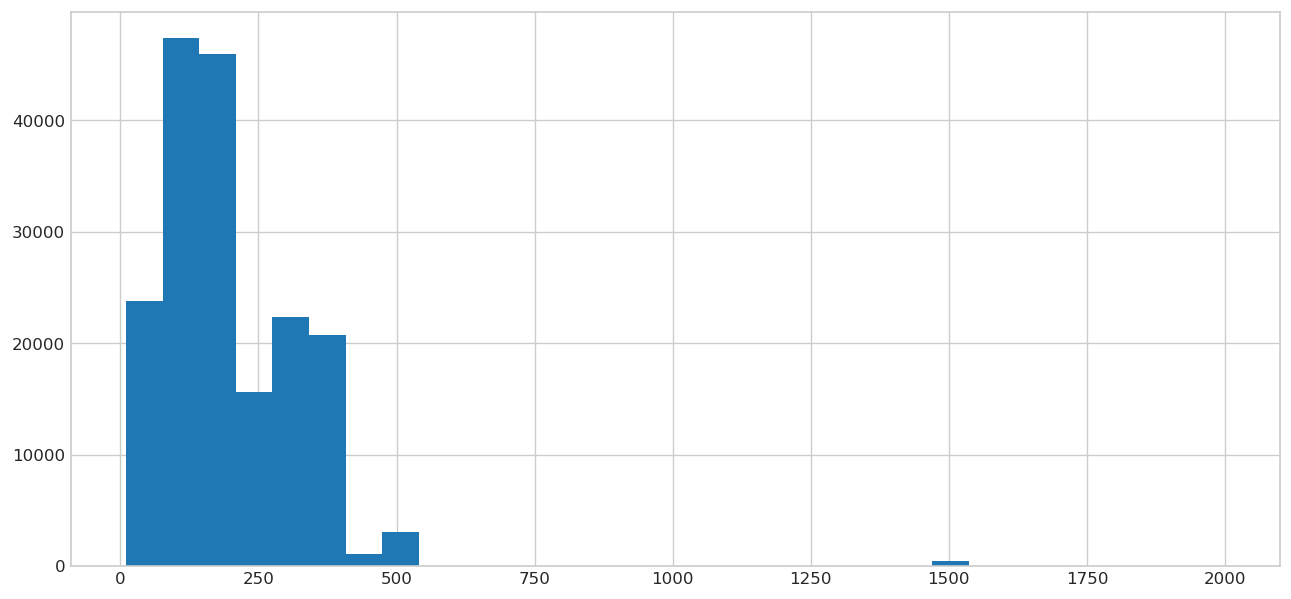

In [225]:
df['sales'].hist(bins=30)


<Axes: xlabel='sales'>

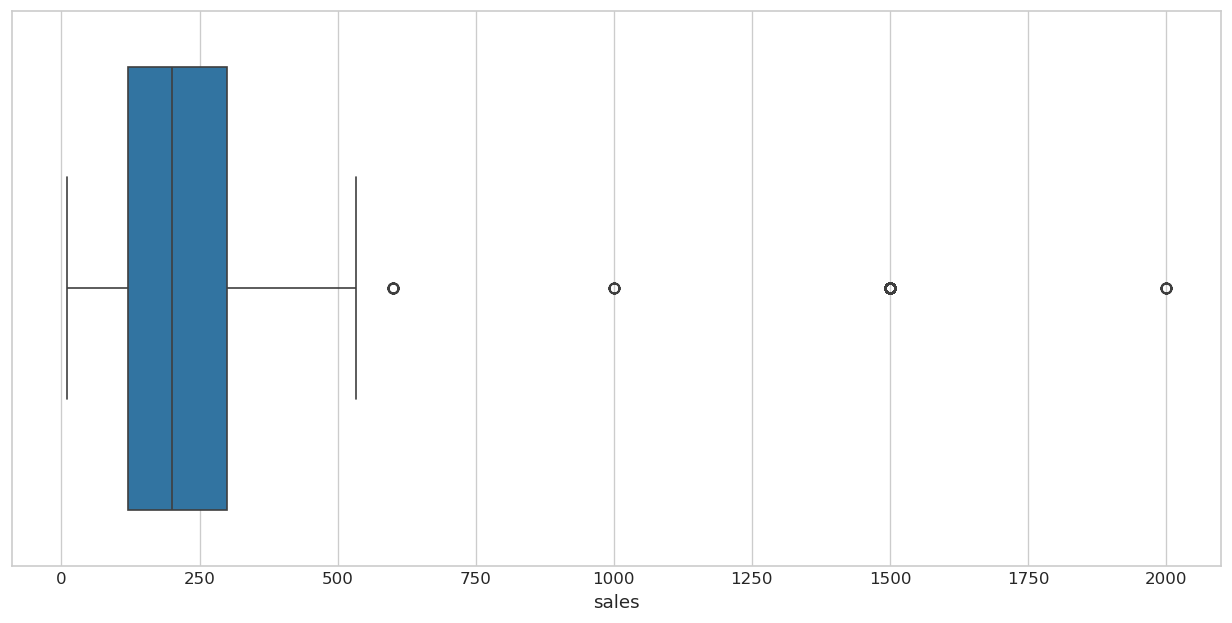

In [226]:
sns.boxplot(x=df['sales'])



<Axes: xlabel='sales', ylabel='Density'>

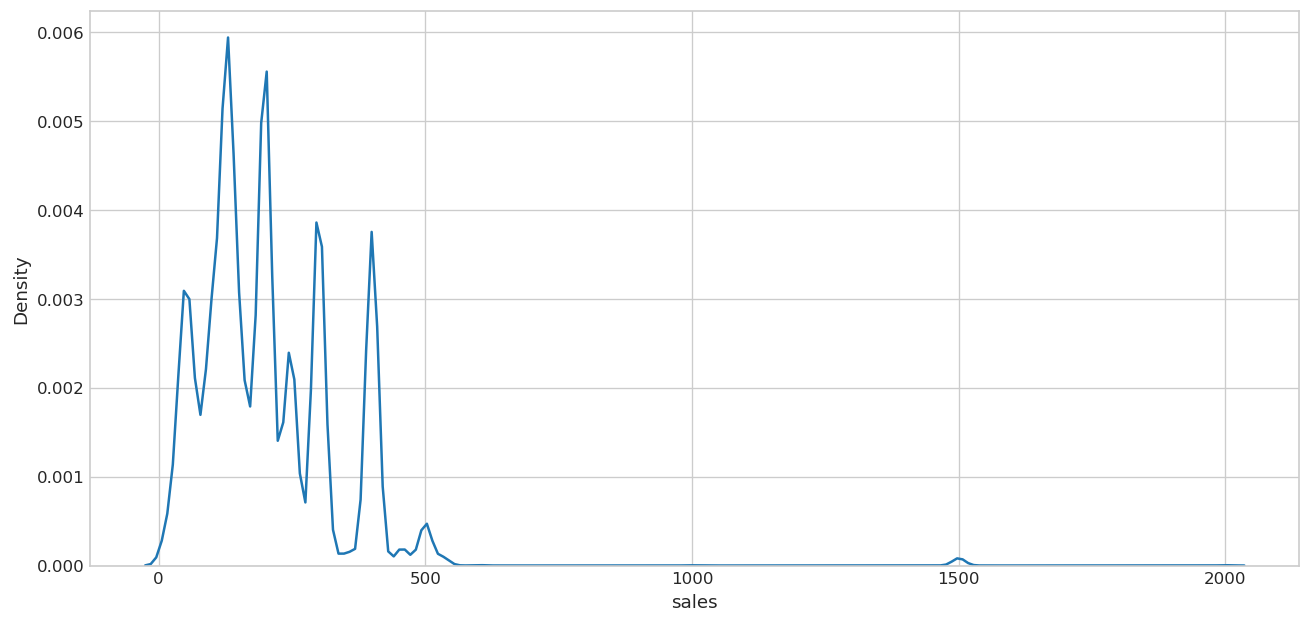

In [227]:
sns.kdeplot(df['sales'])



In [228]:
df['shipping_mode'].value_counts()



shipping_mode
Standard Class    107752
Second Class       35216
First Class        27814
Same Day            9737
Name: count, dtype: int64

In [229]:
df['shipping_mode'].nunique()



4

<Axes: xlabel='shipping_mode', ylabel='count'>

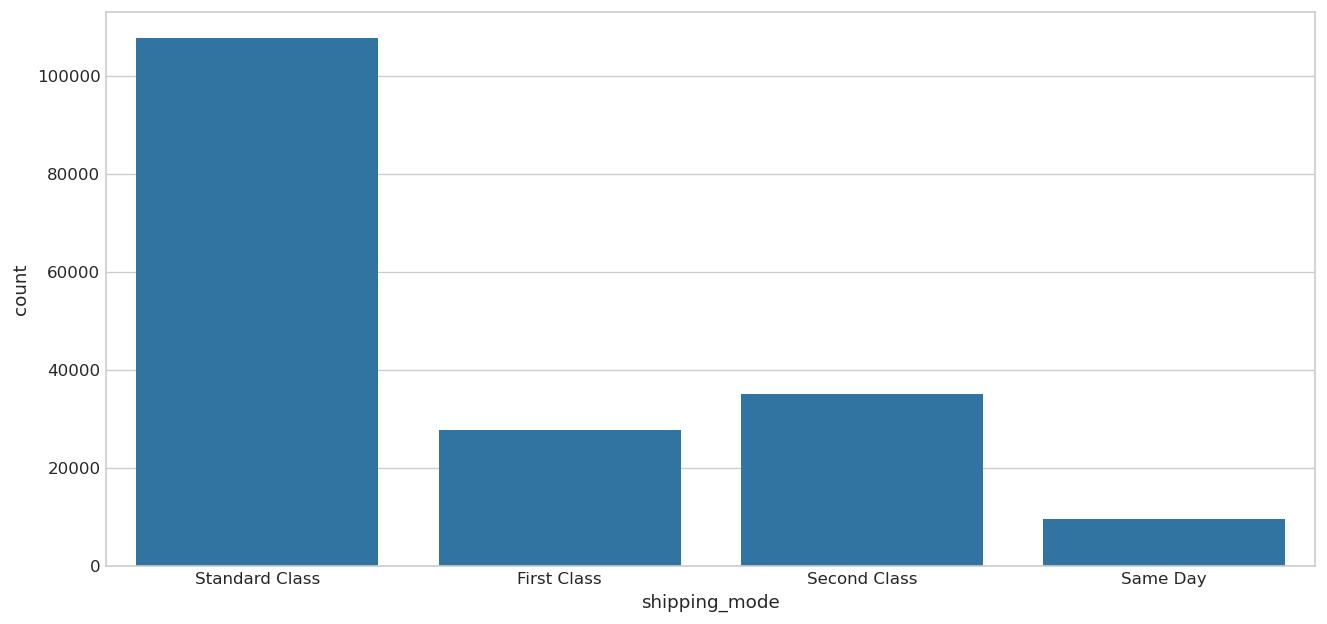

In [230]:
sns.countplot(x='shipping_mode', data=df)



<Axes: ylabel='count'>

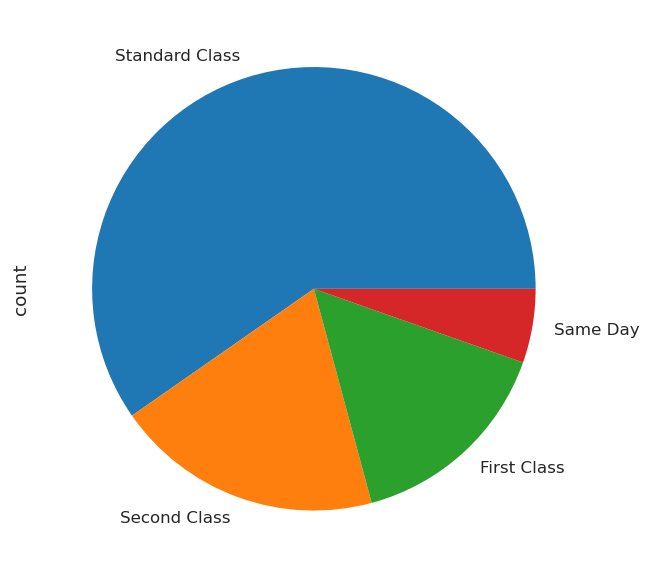

In [231]:
df['shipping_mode'].value_counts().plot.pie()



In [232]:
df['order_profit_per_order'].describe()

count    180519.000000
mean         21.974989
std         104.433526
min       -4274.979980
25%           7.000000
50%          31.520000
75%          64.800003
max         911.799988
Name: order_profit_per_order, dtype: float64

In [233]:
df['order_profit_per_order'].skew(),df['order_profit_per_order'].kurt()

(np.float64(-4.7418340702639625), np.float64(71.37725865589994))

<Axes: >

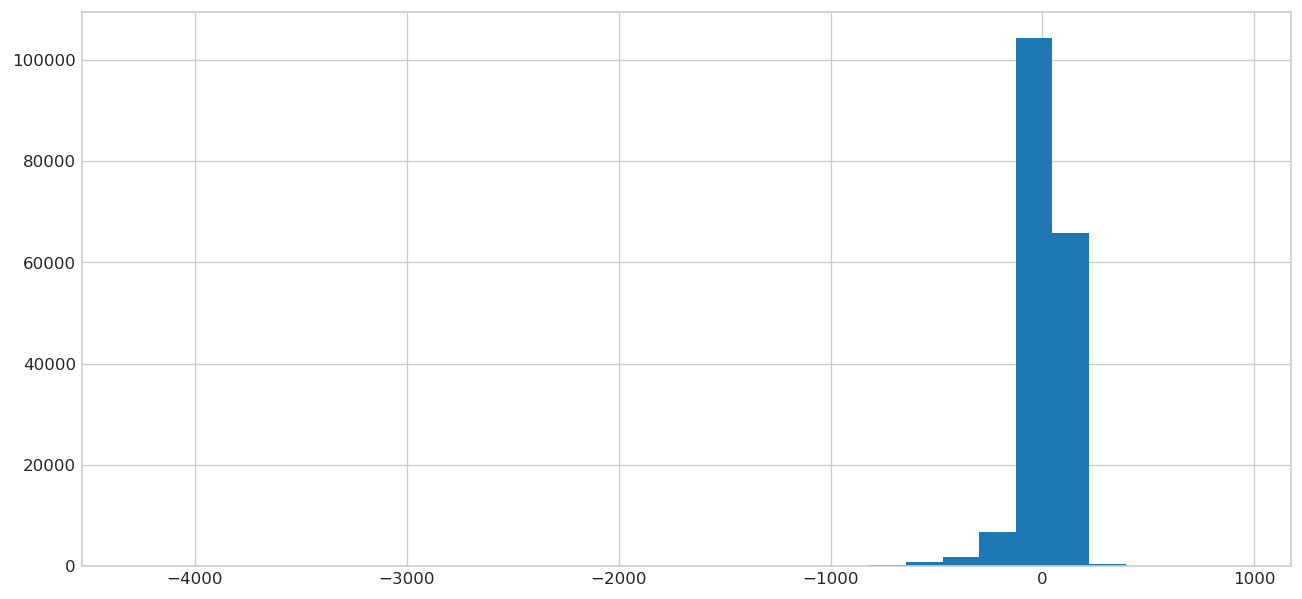

In [234]:
df['order_profit_per_order'].hist(bins =30)

<Axes: xlabel='order_profit_per_order'>

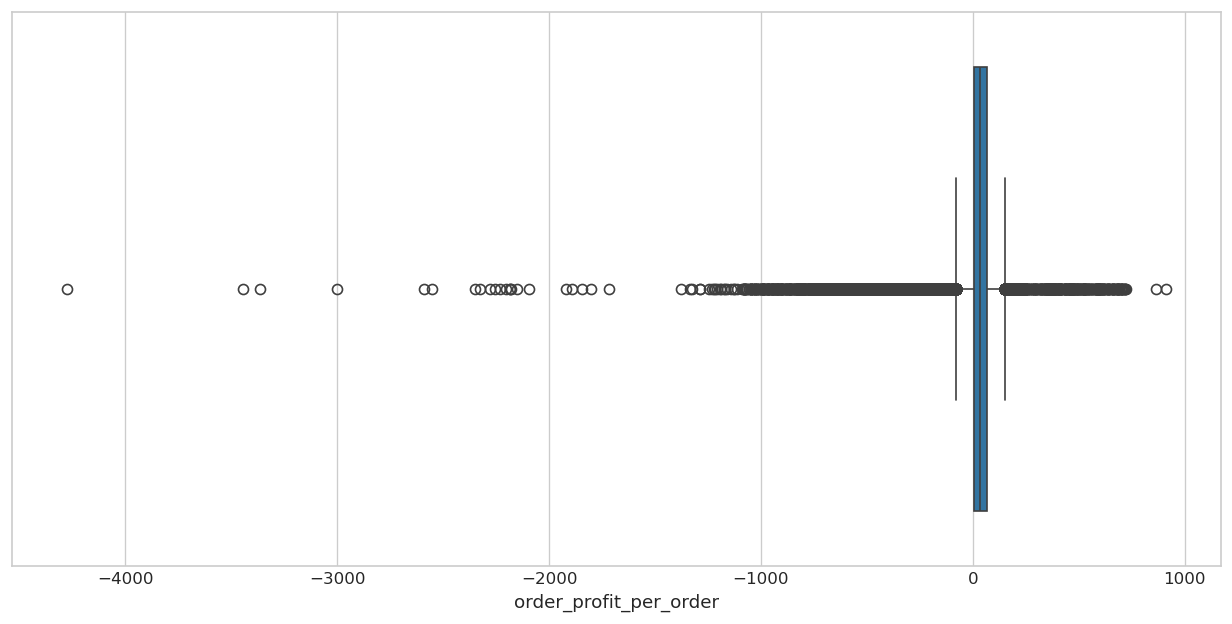

In [235]:
sns.boxplot(x=df['order_profit_per_order'])

This boxplot shows that most orders have similar profit, as the box is very small.
But there are many outliers, which means some orders have very high profit and some have very low or negative profit.
So the data is not evenly distributed and has extreme values
Many dots are far away from the box
Some are on left (low/negative profit)
Some are on right (very high profit)

<Axes: xlabel='order_profit_per_order', ylabel='Density'>

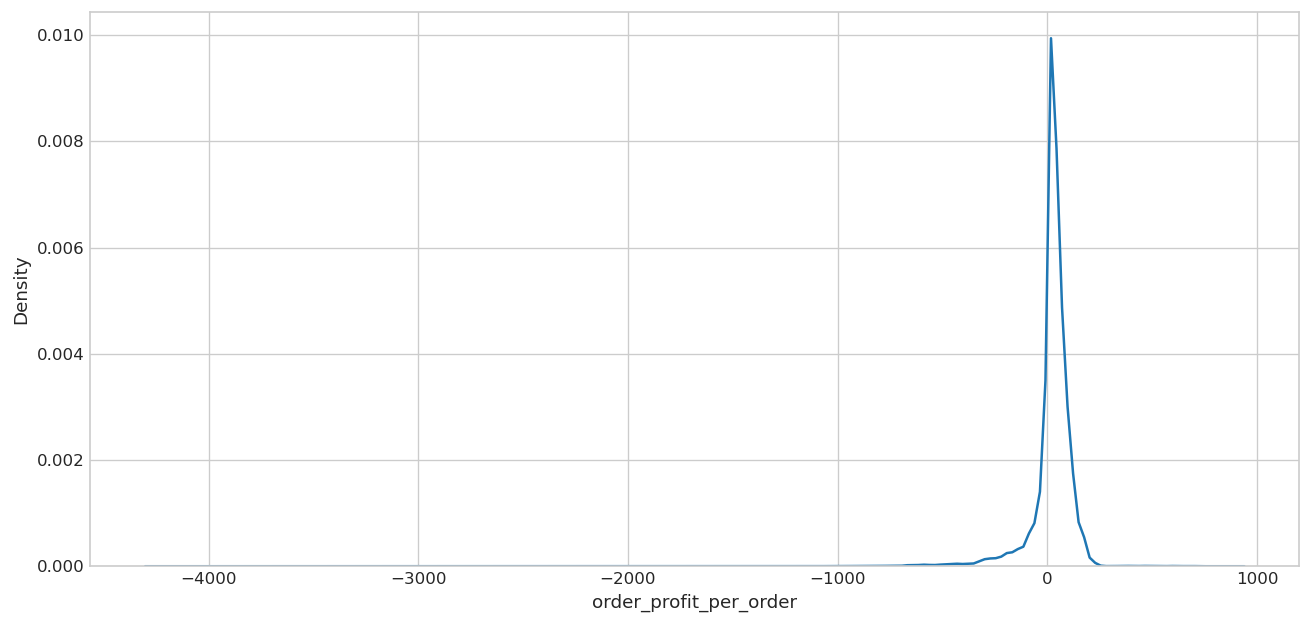

In [236]:
sns.kdeplot(df['order_profit_per_order'])

This KDE plot shows that most orders have profit near zero, as there is a sharp peak in the center.
However, the distribution is skewed because there are extreme negative values (losses) and some high positive profits.
So the data is not balanced and contains outliers

In [237]:
df['profit_margin_pct'].describe()

count    180519.000000
mean         10.832485
std          42.059324
min        -275.000000
25%           6.220000
50%          24.250000
75%          33.600000
max          50.040000
Name: profit_margin_pct, dtype: float64

In [238]:
df['profit_margin_pct'].skew(),df['profit_margin_pct'].kurt()

(np.float64(-2.9108510647452897), np.float64(10.434086156817205))

The skewness is -2.91, which means the data is highly left-skewed, indicating extreme negative values. The kurtosis is 10.43, which is very high, showing that the dataset contains significant outliers.

<Axes: >

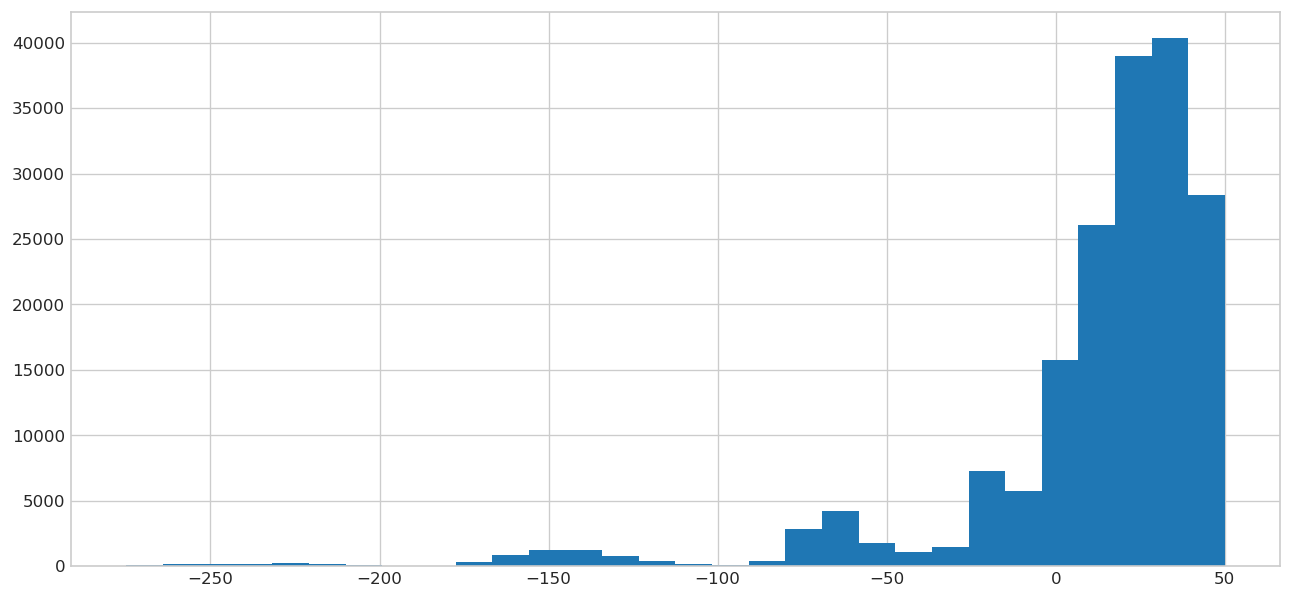

In [239]:
df['profit_margin_pct'].hist(bins=30)

This histogram shows that most orders have a positive profit margin, as the highest bars are on the right side. However, there are some negative values, and a few extreme losses, which create a long tail on the left side. So the data is left-skewed

<Axes: xlabel='profit_margin_pct'>

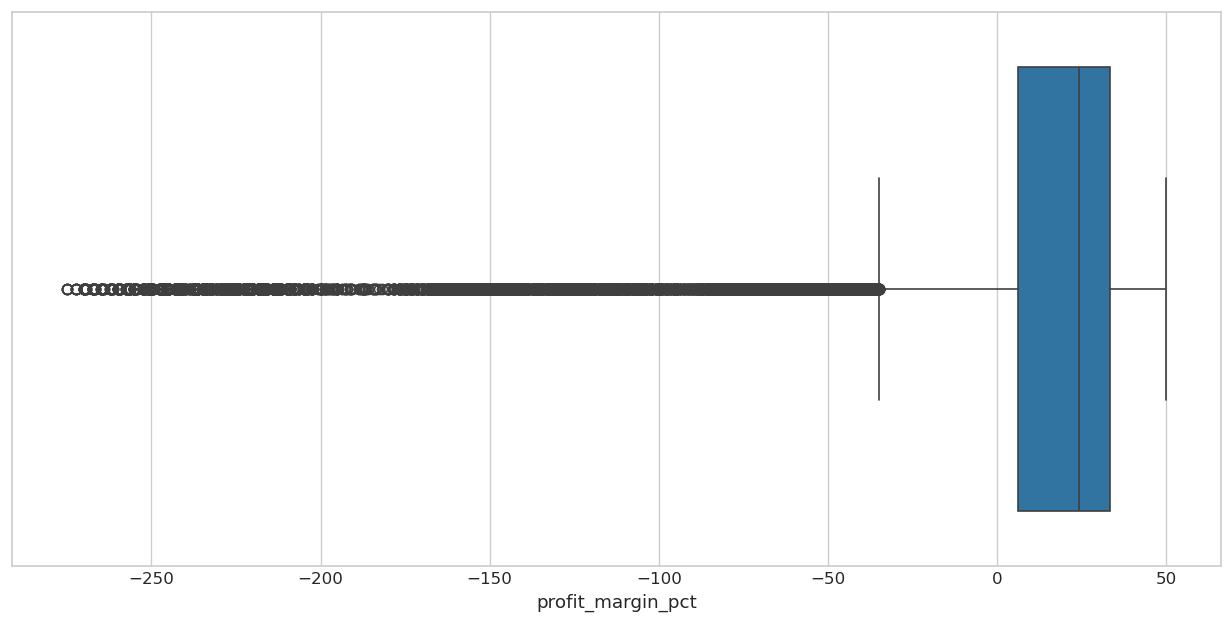

In [240]:
sns.boxplot(x = df['profit_margin_pct'])

This boxplot shows that most orders have a positive profit margin between 10% and 40%, with a median around 25%. However, there are many extreme negative outliers, indicating that some orders are making significant losses. The distribution is highly left-skewed

<Axes: xlabel='profit_margin_pct', ylabel='Density'>

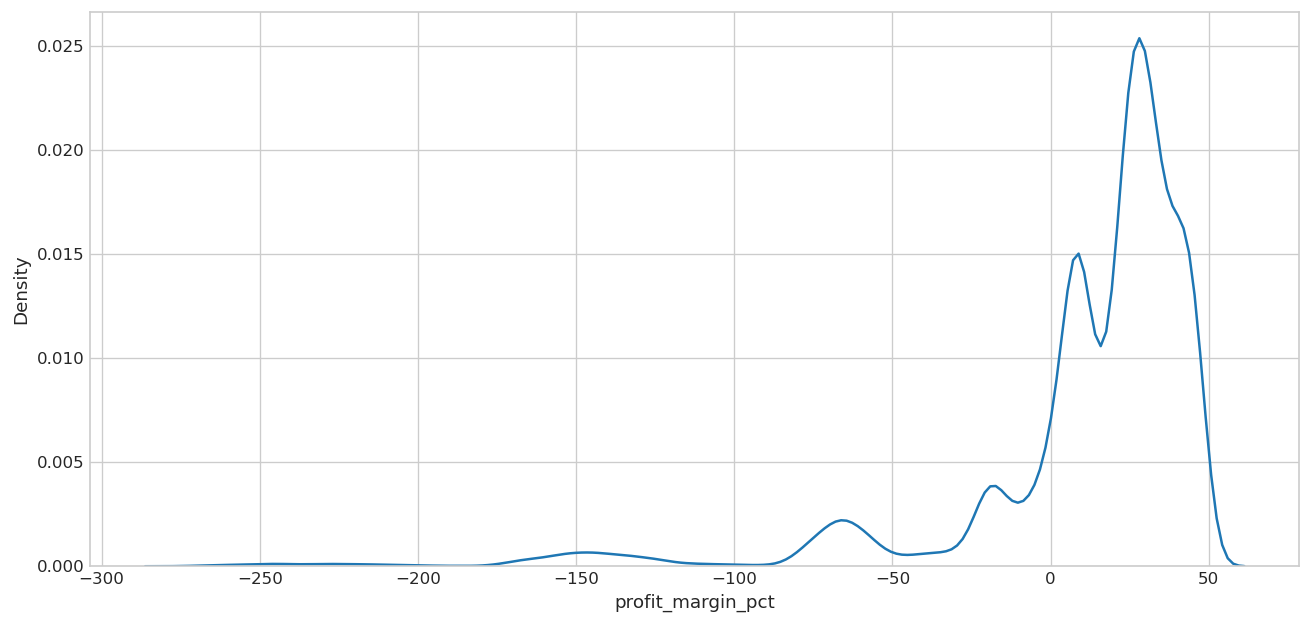

In [241]:
sns.kdeplot(df['profit_margin_pct'])

This KDE plot shows that most orders have a profit margin between 20% and 35%, where the density is highest. However, the distribution is left-skewed with a long tail, indicating the presence of some extreme loss-making orders

In [242]:
df['days_for_shipping_real'].describe()

count    180519.000000
mean          3.497654
std           1.623722
min           0.000000
25%           2.000000
50%           3.000000
75%           5.000000
max           6.000000
Name: days_for_shipping_real, dtype: float64

In [243]:
df['days_for_shipping_real'].skew(),df['days_for_shipping_real'].kurt()

(np.float64(0.0847712729952845), np.float64(-1.0079135834813684))

The skewness is close to zero, which means the shipping time is fairly symmetric. The kurtosis is negative, indicating a flatter distribution with fewer extreme values. This suggests that most deliveries happen within a consistent time range without major delays or outliers.

<Axes: >

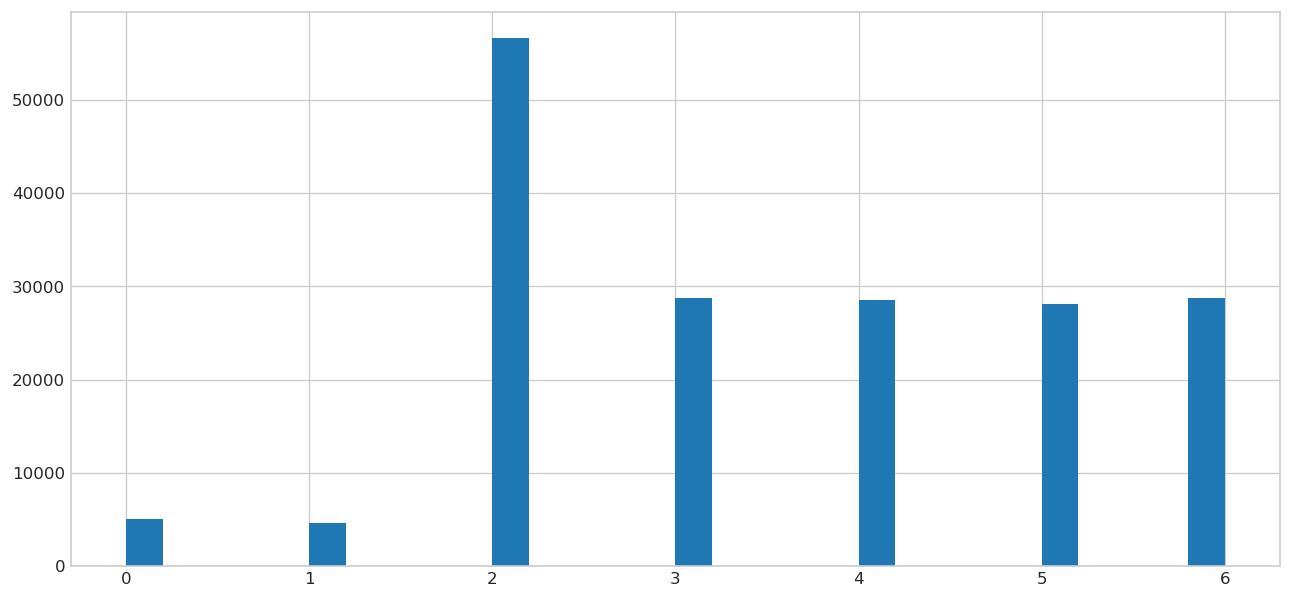

In [244]:
df['days_for_shipping_real'].hist(bins=30)

<Axes: ylabel='days_for_shipping_real'>

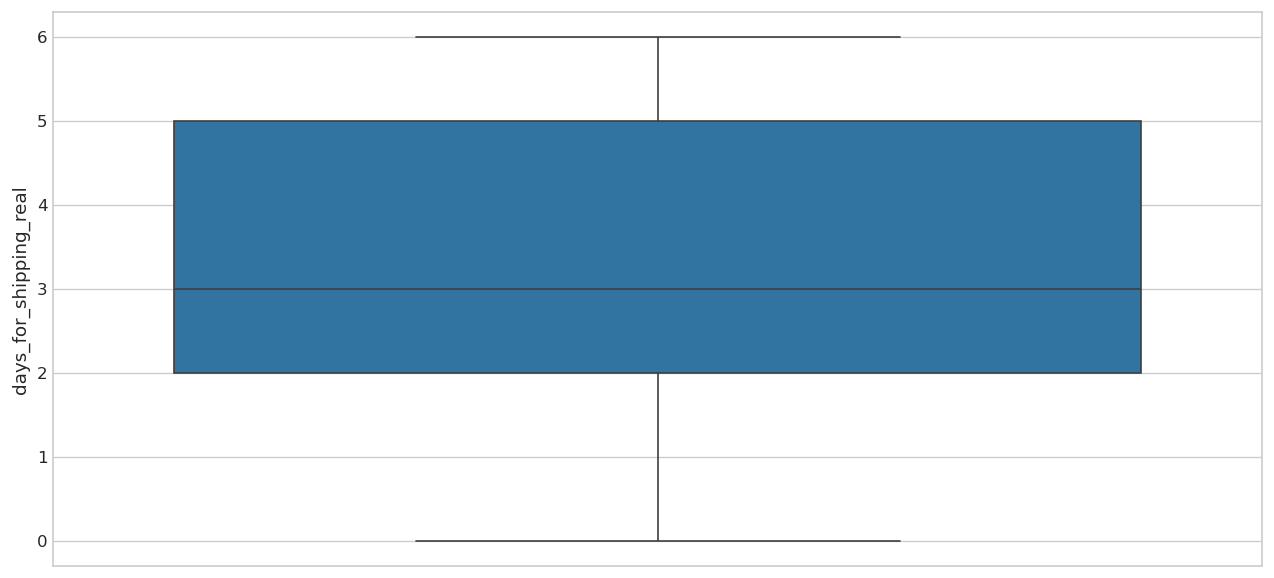

In [245]:
sns.boxplot(df['days_for_shipping_real'])

<Axes: xlabel='days_for_shipping_real', ylabel='Density'>

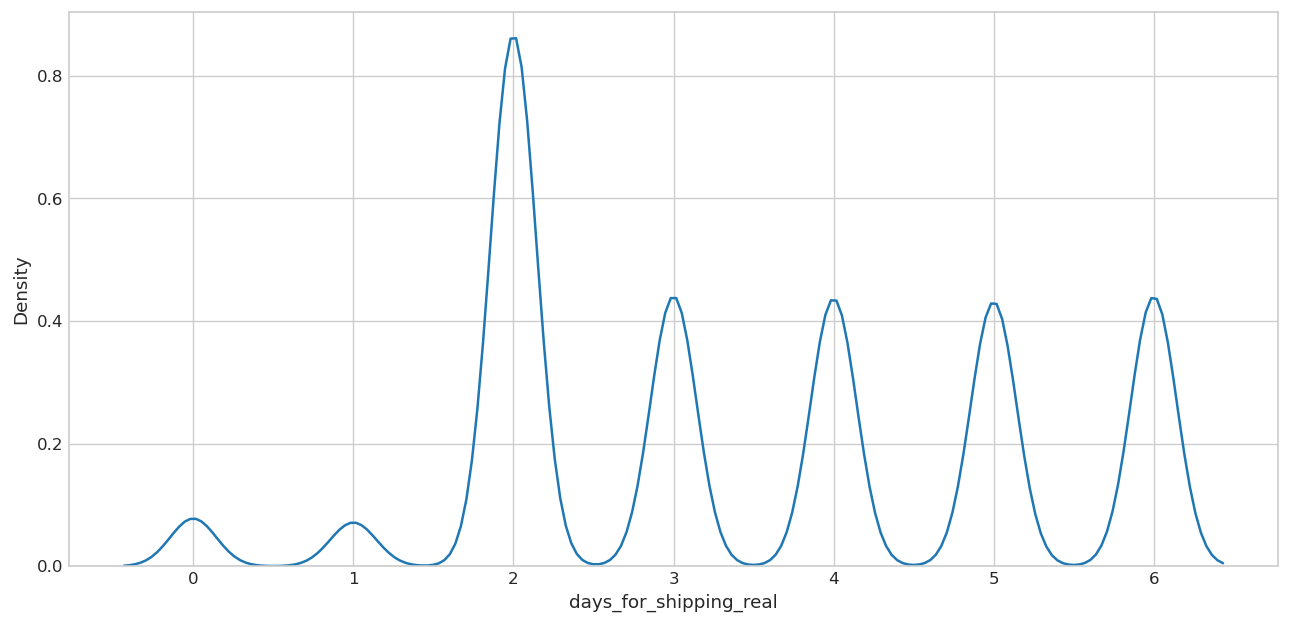

In [246]:
sns.kdeplot(x = df['days_for_shipping_real'])

In [247]:
df['delivery_gap_days'].describe()

count    180519.000000
mean          0.565807
std           1.490966
min          -2.000000
25%           0.000000
50%           1.000000
75%           1.000000
max           4.000000
Name: delivery_gap_days, dtype: float64

In [248]:
df['delivery_gap_days'].skew(),df['delivery_gap_days'].kurt()

(np.float64(0.031464434166037086), np.float64(-0.2922369700650309))

<Axes: >

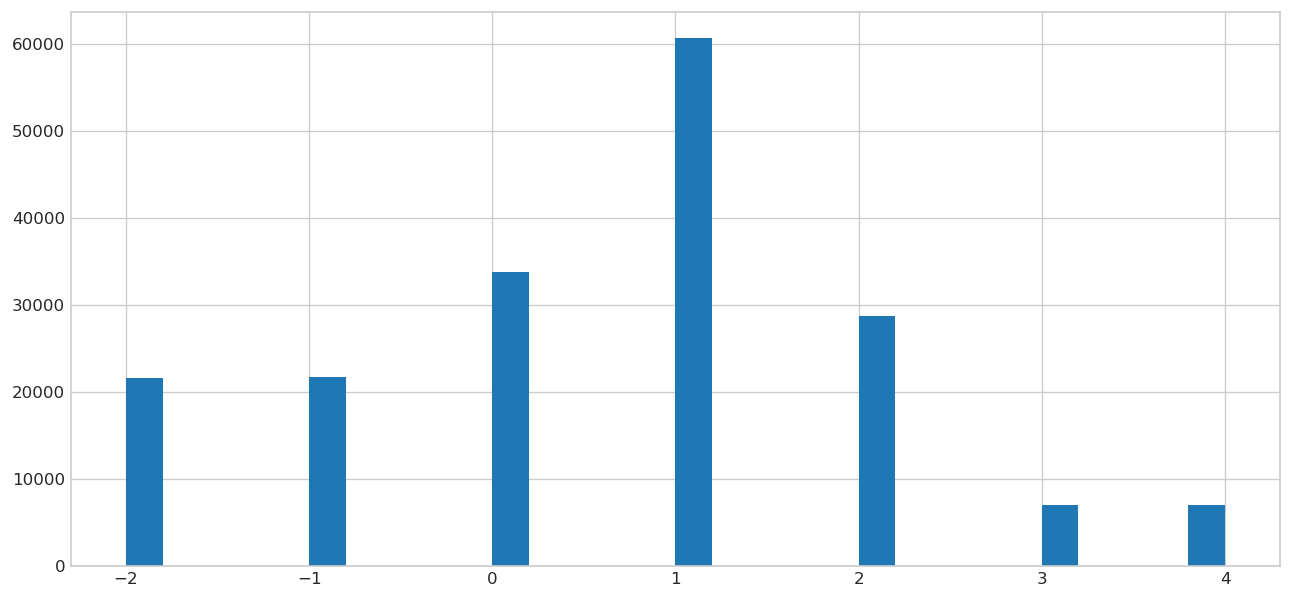

In [249]:
df['delivery_gap_days'].hist(bins=30)

<Axes: ylabel='delivery_gap_days'>

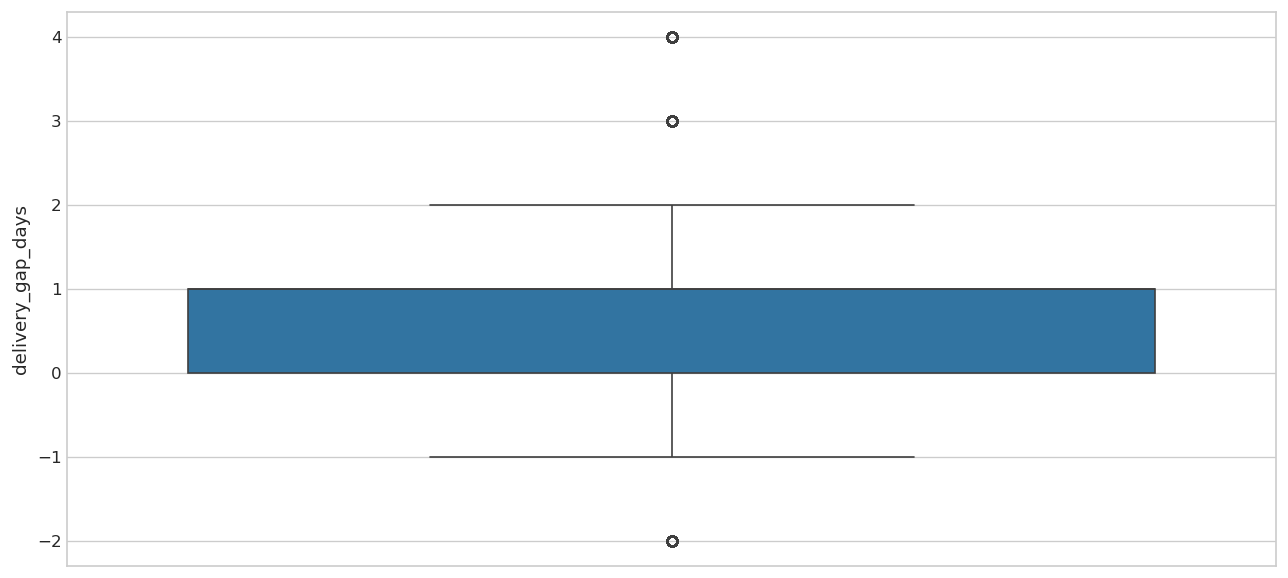

In [250]:
sns.boxplot(df['delivery_gap_days'])

<Axes: xlabel='delivery_gap_days', ylabel='Density'>

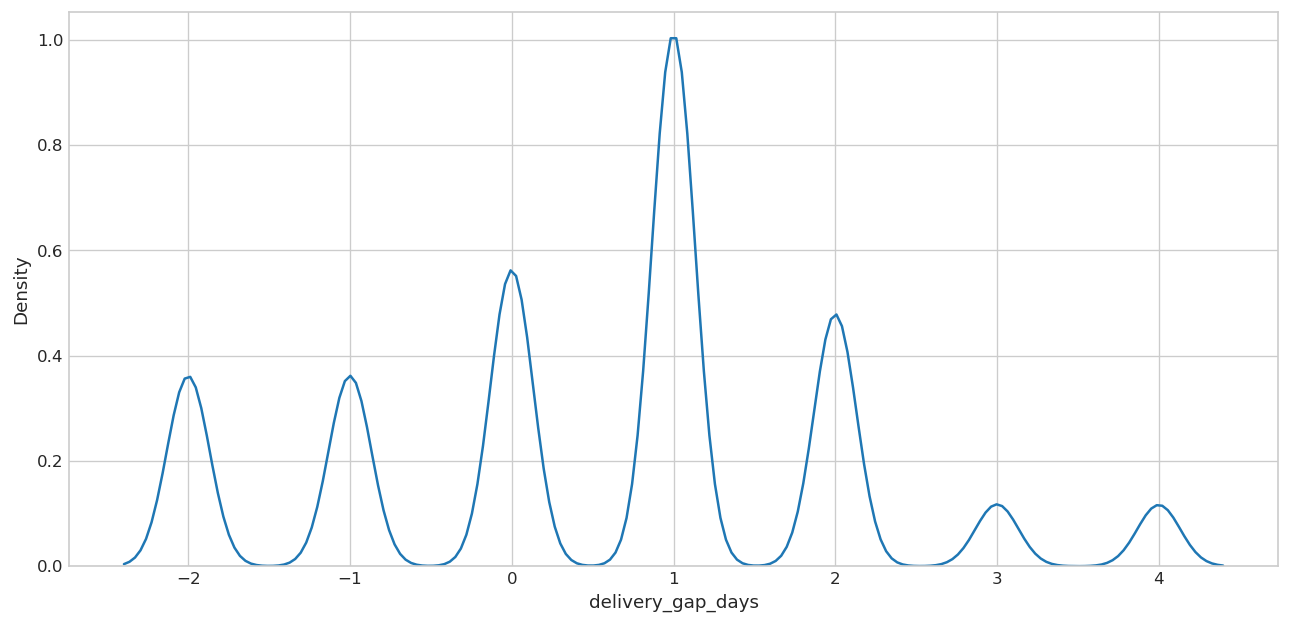

In [251]:
sns.kdeplot(x = df['delivery_gap_days'])

In [252]:
df['customer_segment'].value_counts()

customer_segment
Consumer       93504
Corporate      54789
Home Office    32226
Name: count, dtype: int64

In [253]:
df['customer_segment'].nunique()

3

<Axes: xlabel='customer_segment', ylabel='count'>

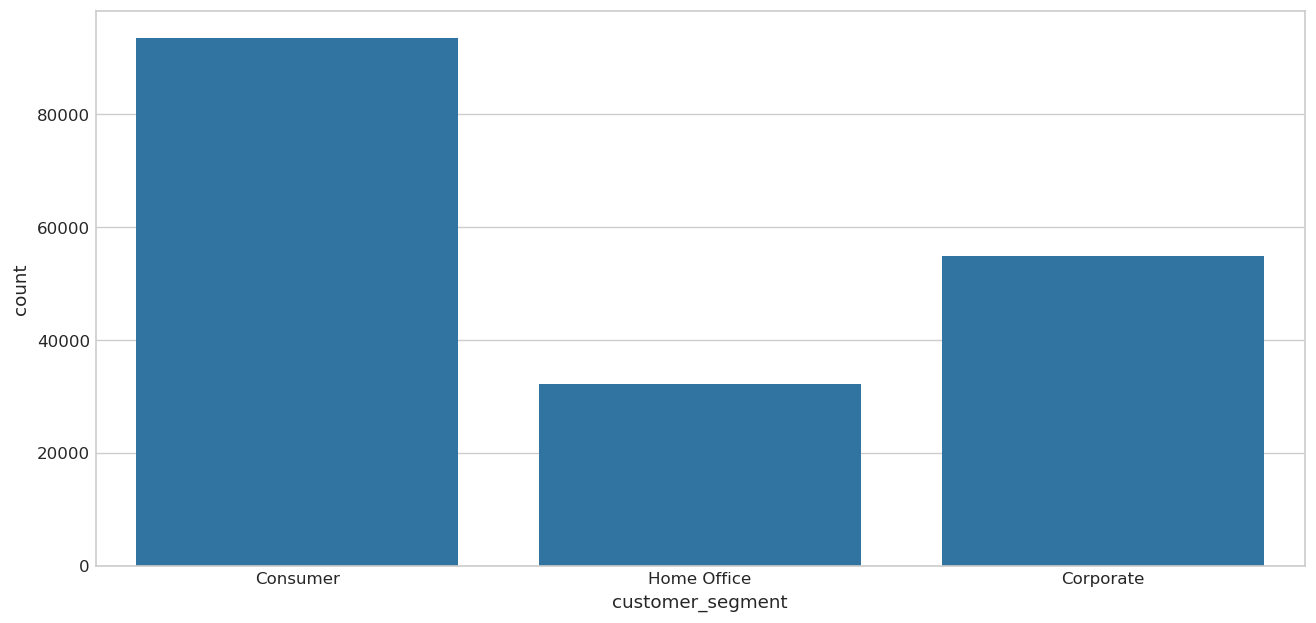

In [254]:
sns.countplot(x='customer_segment', data=df)

<Axes: ylabel='count'>

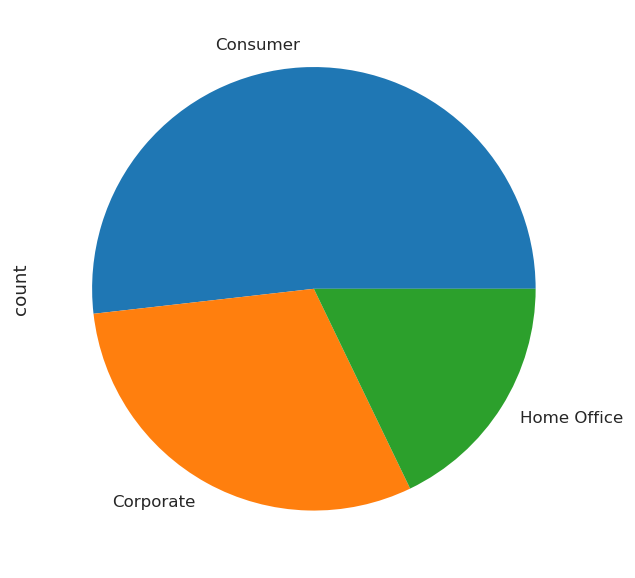

In [255]:
df['customer_segment'].value_counts().plot.pie()


In [256]:
df['market'].value_counts()

market
LATAM           51594
Europe          50252
Pacific Asia    41260
USCA            25799
Africa          11614
Name: count, dtype: int64

In [257]:
df['market'].nunique()

5

<Axes: xlabel='market', ylabel='count'>

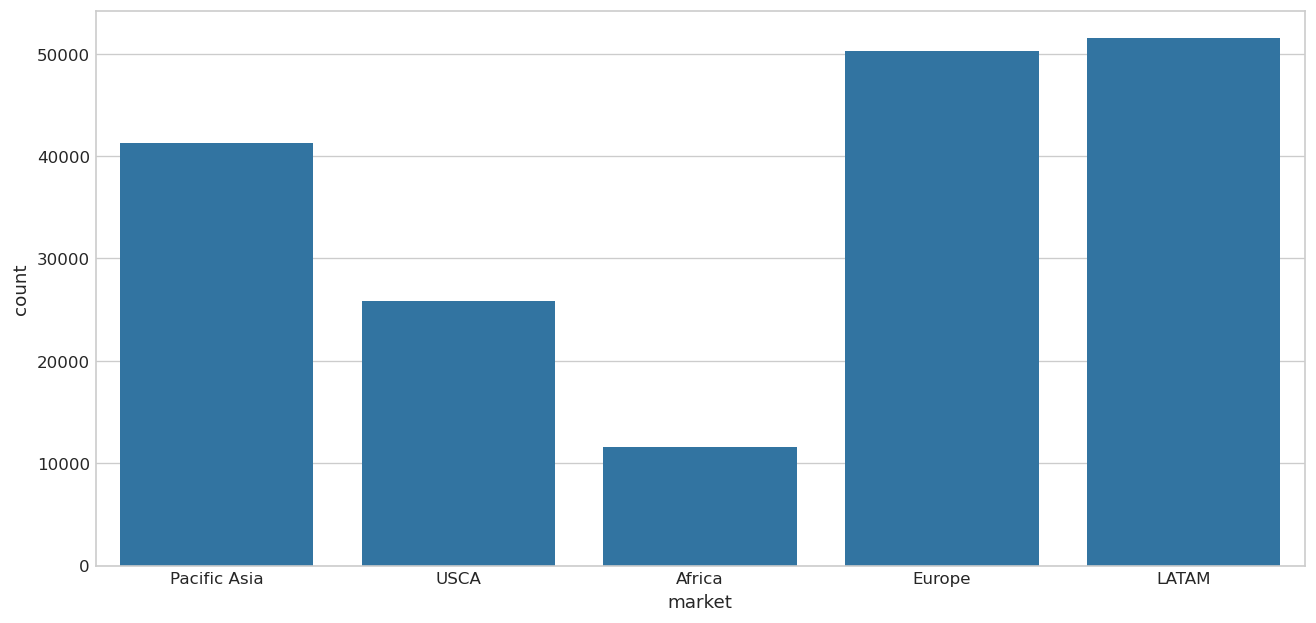

In [258]:
sns.countplot(x= 'market',data=df)

<Axes: ylabel='count'>

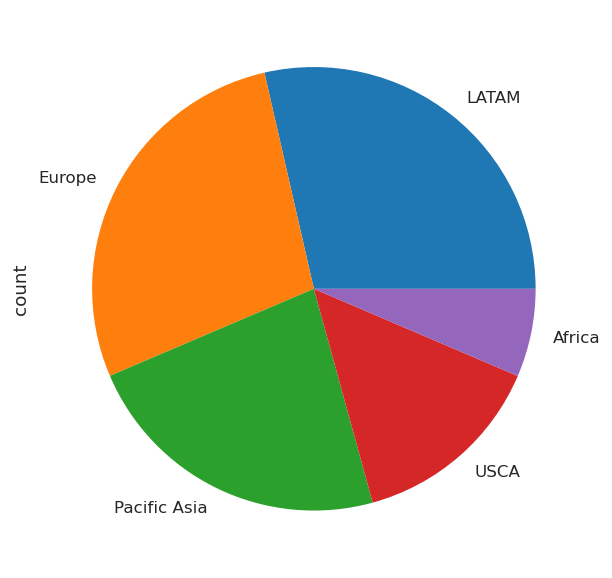

In [259]:
df['market'].value_counts().plot.pie()

In [260]:
df['delivery_status'].value_counts()

delivery_status
Late delivery        98977
Advance shipping     41592
Shipping on time     32196
Shipping canceled     7754
Name: count, dtype: int64

In [261]:
df['delivery_status'].nunique()

4

<Axes: xlabel='delivery_status', ylabel='count'>

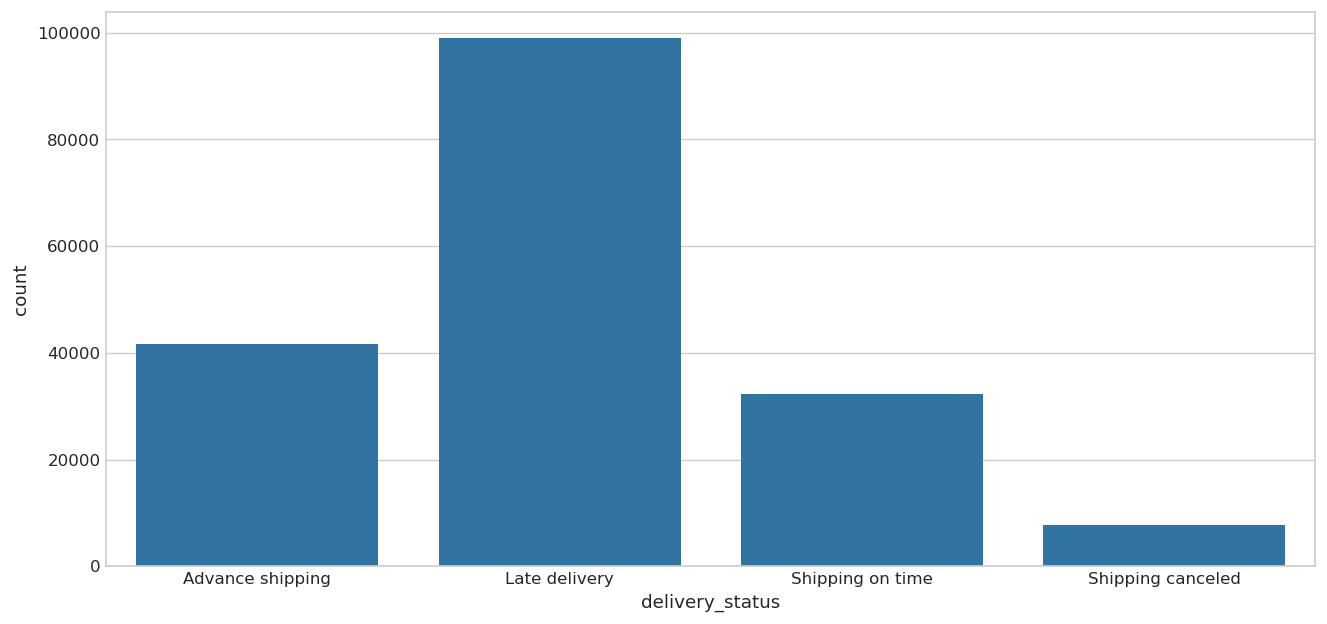

In [262]:
sns.countplot(x = 'delivery_status' , data =df)

<Axes: ylabel='count'>

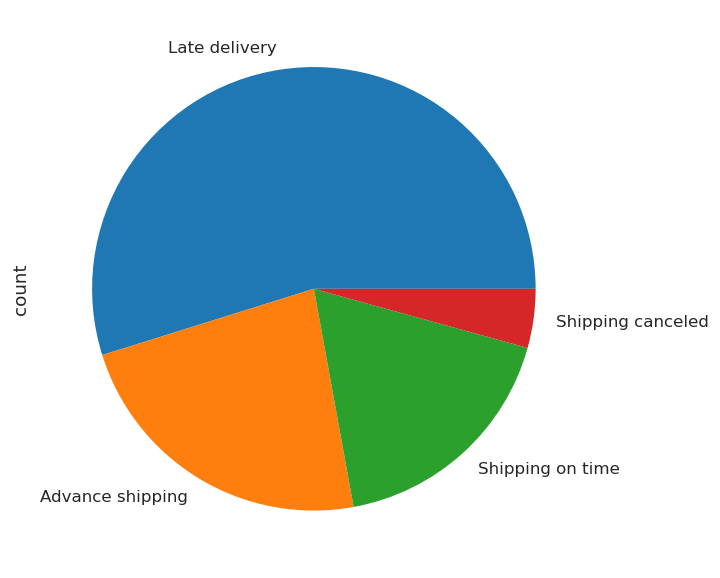

In [263]:
df['delivery_status'].value_counts().plot.pie()

**Revenue vs Profit Margin by Category**

In [264]:
# Business Q1: Do high-revenue categories also have best margins?
 
# Build the data
cat_data = (
    df.groupby('category_name')
    .agg(
        total_revenue = ('sales', 'sum'),
        total_profit  = ('order_profit_per_order', 'sum')
        
    )
    .assign(margin_pct = lambda x: (x.total_profit / x.total_revenue * 100).round(1))
    .sort_values('total_revenue', ascending=False)
    .head(12)
)


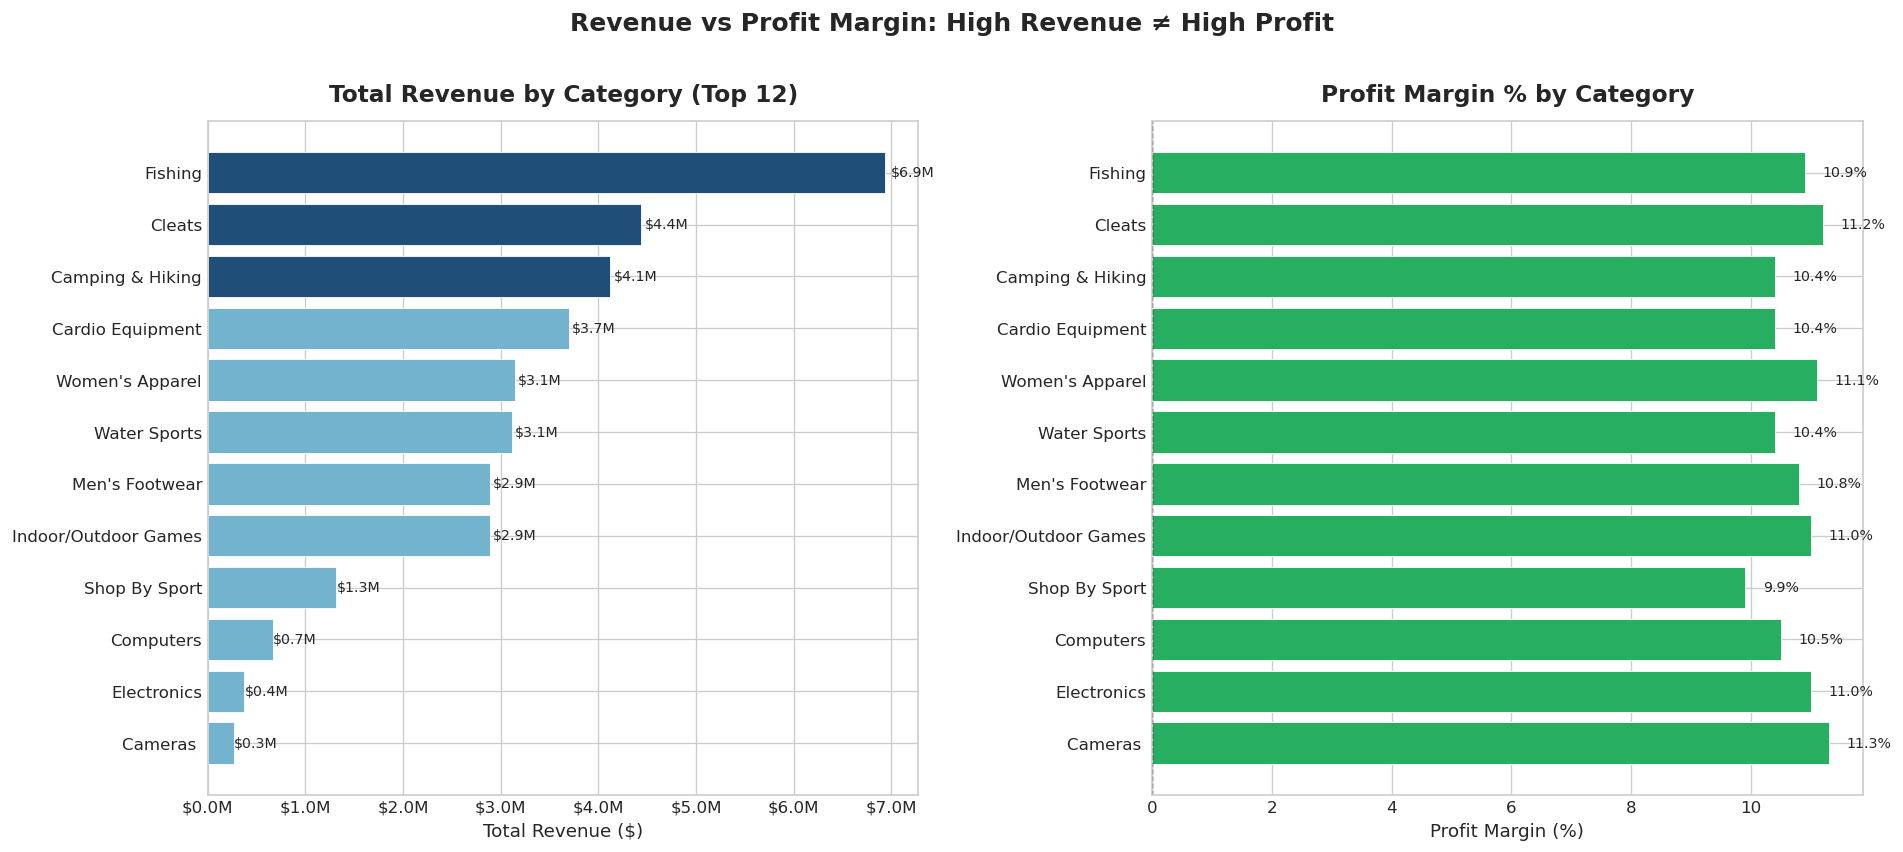

Chart 1 saved.


In [265]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
 
# ---- Left: Revenue bar ----
colors_rev = [MAIN_BLUE if i < 3 else '#74B3CE' for i in range(len(cat_data))]
bars = axes[0].barh(cat_data.index, cat_data['total_revenue'],
                    color=colors_rev, edgecolor='white', linewidth=0.5)
axes[0].set_title('Total Revenue by Category (Top 12)', pad=12)
axes[0].set_xlabel('Total Revenue ($)')
axes[0].invert_yaxis()
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))
# Add value labels
for bar in bars:
    w = bar.get_width()
    axes[0].text(w * 1.01, bar.get_y() + bar.get_height()/2,
                 f'${w/1e6:.1f}M', va='center', fontsize=8.5)
# ---- Right: Profit margin bar ----
colors_margin = [SUCCESS_GREEN if v >= 0 else DANGER_RED for v in cat_data['margin_pct']]
bars2 = axes[1].barh(cat_data.index, cat_data['margin_pct'],
                     color=colors_margin, edgecolor='white', linewidth=0.5)
axes[1].set_title('Profit Margin % by Category', pad=12)
axes[1].set_xlabel('Profit Margin (%)')
axes[1].invert_yaxis()
axes[1].axvline(x=0, color='black', linewidth=0.8, linestyle='--')
for bar in bars2:
    w = bar.get_width()
    offset = 0.3 if w >= 0 else -3
    axes[1].text(w + offset, bar.get_y() + bar.get_height()/2,
                 f'{w:.1f}%', va='center', fontsize=8.5)
 
plt.suptitle('Revenue vs Profit Margin: High Revenue ≠ High Profit',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()

plt.show()
print('Chart 1 saved.')


**Revenue vs Profit Margin Analysis**
Fishing category generates the highest total revenue, making it the strongest revenue contributor.The business is dependent on a small number of high-performing categories for revenue generation. Any decline in these categories could significantly impact overall sales.
Profit margins appear relatively strong across most categories, indicating healthy profitability.
The variation between categories suggests some product groups are more cost-efficient than others.
Categories with consistently high margins contribute more profit per dollar of sales and should be prioritized during business expansion.

**Late Delivery Rate by Shipping Mode**

Which shipping modes fail customers most often? Is the premium shipping tier actually performing better?

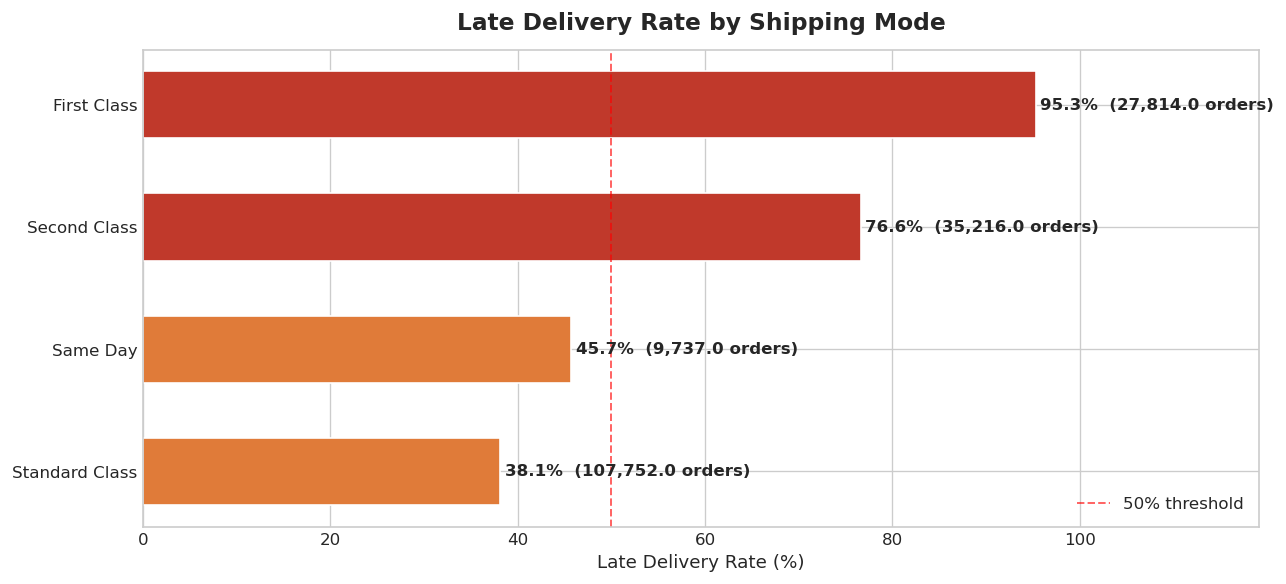

In [266]:
ship_perf = (
    df.groupby('shipping_mode')
    .agg(total=('order_id','count'), late=('is_late_delivery','sum'))
    .assign(late_pct = lambda x: (x.late / x.total * 100).round(1))
    .sort_values('late_pct', ascending=True)
)
 
fig, ax = plt.subplots(figsize=(11, 5))
 
# Colour: red if >50% late, orange if >30%, green otherwise
colors = []
for val in ship_perf['late_pct']:
    if val > 50:   colors.append(DANGER_RED)
    elif val > 30: colors.append(ACCENT_ORANGE)
    else:          colors.append(SUCCESS_GREEN)
 
bars = ax.barh(ship_perf.index, ship_perf['late_pct'],
               color=colors, edgecolor='white', height=0.55)
 
# Add value labels and total order counts
for bar, (_, row) in zip(bars, ship_perf.iterrows()):
    w = bar.get_width()
    ax.text(w + 0.5, bar.get_y() + bar.get_height()/2,
            f'{w:.1f}%  ({row["total"]:,} orders)',
            va='center', fontsize=10, fontweight='bold')
 
# Reference line at 50%
ax.axvline(x=50, color='red', linestyle='--', alpha=0.6,
           linewidth=1.2, label='50% threshold')
ax.set_title('Late Delivery Rate by Shipping Mode', pad=12)
ax.set_xlabel('Late Delivery Rate (%)')
ax.set_xlim(0, max(ship_perf['late_pct']) * 1.25)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()


First Class shipping shows the highest late delivery rate , making it the least reliable shipping option.
Second Class shipping also experiences a relatively high delay rate.
Same Day shipping, despite being the fastest service, still has a notable percentage of delayed deliveries.
Standard Class has the lowest late delivery rate among the shipping methods shown.
Faster shipping options are not necessarily delivering better reliability, which may negatively impact customer satisfaction.

Frequent delays in First Class and Same Day shipping can lead to:
Customer complaints
Negative reviews
Increased support tickets
Reduced repeat purchases

Investigate logistics bottlenecks affecting First Class and Same Day shipments.
Review carrier performance and warehouse dispatch times.
Consider setting more realistic delivery promises for high-delay shipping modes.
Create automated alerts for orders at risk of late delivery.

**Monthly Revenue Trend Over Time**

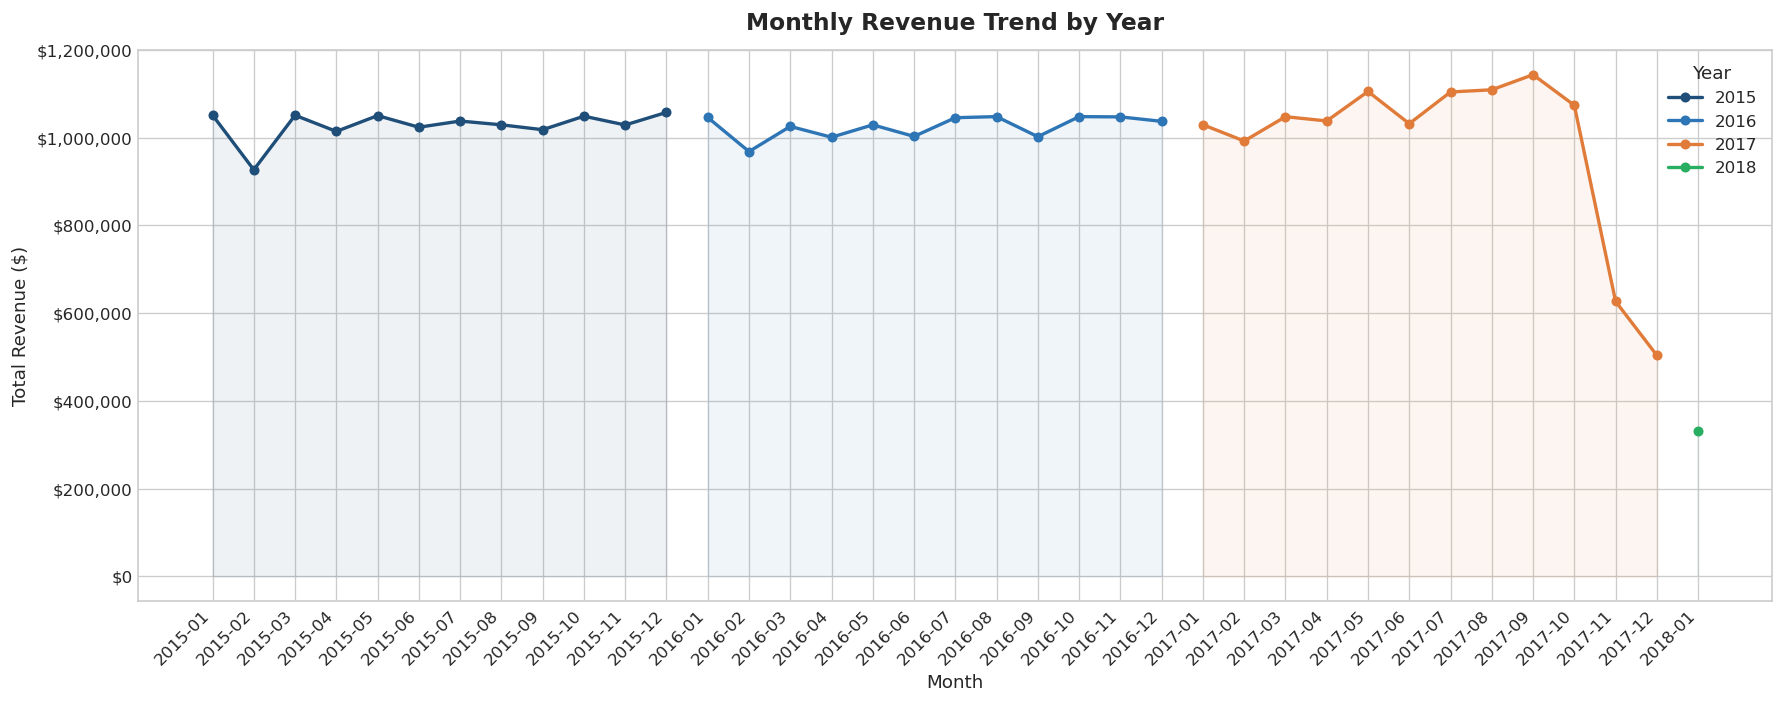

Monthly Revenue Statistics:
  Average monthly revenue: $994,182
  Best month:  2017-09 ($1,143,775)
  Worst month: 2018-01 ($331,650)


In [267]:
# Business Q5: Are there seasonal patterns in revenue?
# ============================================================
 
# Parse order_date if needed
if df['order_date_dateorders'].dtype == object:
    df['order_date_dateorders'] = pd.to_datetime(df['order_date_dateorders'], errors='coerce')
 
monthly = (
    df.groupby([df['order_date_dateorders'].dt.to_period('M')])
    ['sales'].sum()
    .reset_index()
)
monthly.columns = ['period', 'monthly_revenue']
monthly['period_str'] = monthly['period'].astype(str)
monthly['year'] = monthly['period'].dt.year
 
fig, ax = plt.subplots(figsize=(15, 6))
 
# Plot one line per year with different colours
year_colors = {2015: '#1F4E79', 2016: '#2E75B6', 2017: '#E07B39', 2018: '#27AE60'}
years = sorted(monthly['year'].unique())
 
for yr in years:
    yr_data = monthly[monthly['year'] == yr]
    color = year_colors.get(yr, '#888888')
    ax.plot(yr_data['period_str'], yr_data['monthly_revenue'],
            marker='o', linewidth=2, markersize=5,
            color=color, label=str(yr))
    ax.fill_between(yr_data['period_str'], yr_data['monthly_revenue'],
                    alpha=0.07, color=color)
 
ax.set_title('Monthly Revenue Trend by Year', pad=12)
ax.set_xlabel('Month')
ax.set_ylabel('Total Revenue ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'${x:,.0f}'))
plt.xticks(rotation=45, ha='right')
ax.legend(title='Year', loc='upper right')
plt.tight_layout()
plt.show()
 
# Print summary stats
print('Monthly Revenue Statistics:')
print(f'  Average monthly revenue: ${monthly["monthly_revenue"].mean():,.0f}')
print(f'  Best month:  {monthly.loc[monthly["monthly_revenue"].idxmax(), "period_str"]} (${monthly["monthly_revenue"].max():,.0f})')
print(f'  Worst month: {monthly.loc[monthly["monthly_revenue"].idxmin(), "period_str"]} (${monthly["monthly_revenue"].min():,.0f})')


**Top 10 Most Profitable Products**

Which specific products drive the most total profit? Are they the same products driving the most revenue?

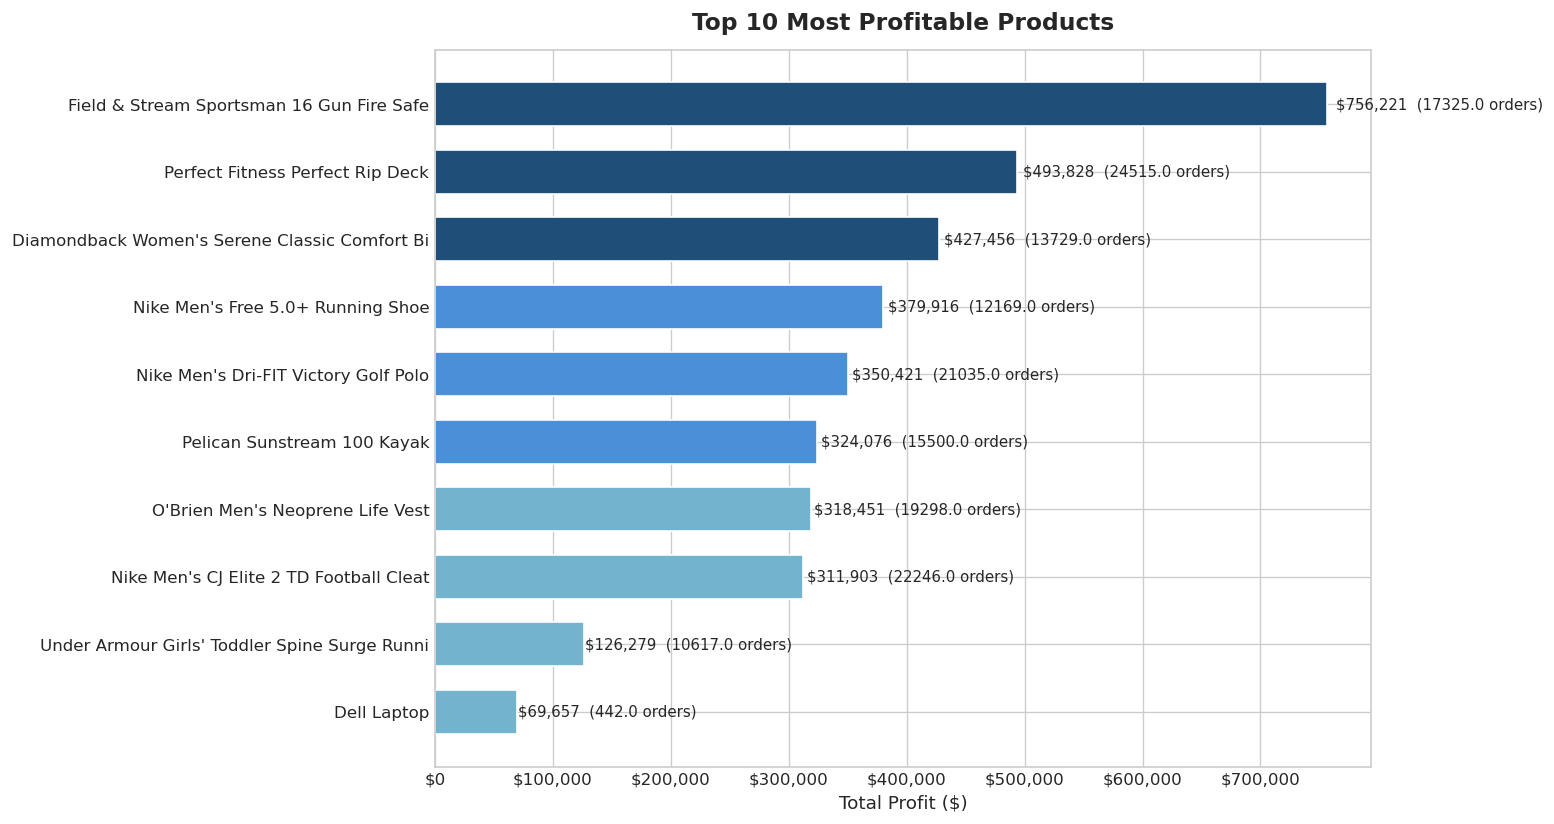

In [211]:
top_products = (
    df.groupby('product_name')
    .agg(
        total_profit  = ('order_profit_per_order', 'sum'),
        total_revenue = ('sales', 'sum'),
        order_count   = ('order_id', 'count')
    )
    .sort_values('total_profit', ascending=False)
    .head(10)
)
 
fig, ax = plt.subplots(figsize=(13, 7))
 
# Gradient colours: top 3 are darkest blue
bar_colors = [MAIN_BLUE if i < 3 else '#4A90D9' if i < 6 else '#74B3CE'
              for i in range(len(top_products))]
bars = ax.barh(top_products.index, top_products['total_profit'],
               color=bar_colors, edgecolor='white', height=0.65)
ax.invert_yaxis()
 
for bar, (_, row) in zip(bars, top_products.iterrows()):
    w = bar.get_width()
    ax.text(w * 1.01, bar.get_y() + bar.get_height()/2,
            f'${w:,.0f}  ({row["order_count"]} orders)',
            va='center', fontsize=9)
 
ax.set_title('Top 10 Most Profitable Products', pad=12)
ax.set_xlabel('Total Profit ($)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'${x:,.0f}'))
plt.tight_layout()
plt.show()


A small group of products contributes a disproportionately large share of total profit.
The highest-profit product significantly outperforms the rest, indicating a strong "star product."
Several technology and office-related products appear among the top profit generators, suggesting these categories drive profitability.
The profit gap between the top-ranked product and lower-ranked products is substantial, showing that profit is concentrated among a few SKUs.
Not all products contribute equally; a large portion of overall profit likely comes from a limited number of items.

The company's profitability is heavily dependent on a small set of high-performing products. These products should be treated as strategic assets because they generate a significant portion of total profit.

Maintain strong inventory availability for top-profit products.
Prioritize these products in marketing campaigns.
Create bundles and cross-selling opportunities around these high-profit items.
Monitor stock-outs closely, as losing sales on these products would have a disproportionate impact on profit.

**Customer Segment: Revenue vs Average Order Value**

Which customer segments generate the most total revenue vs the highest per-order value? Which segments should we grow?

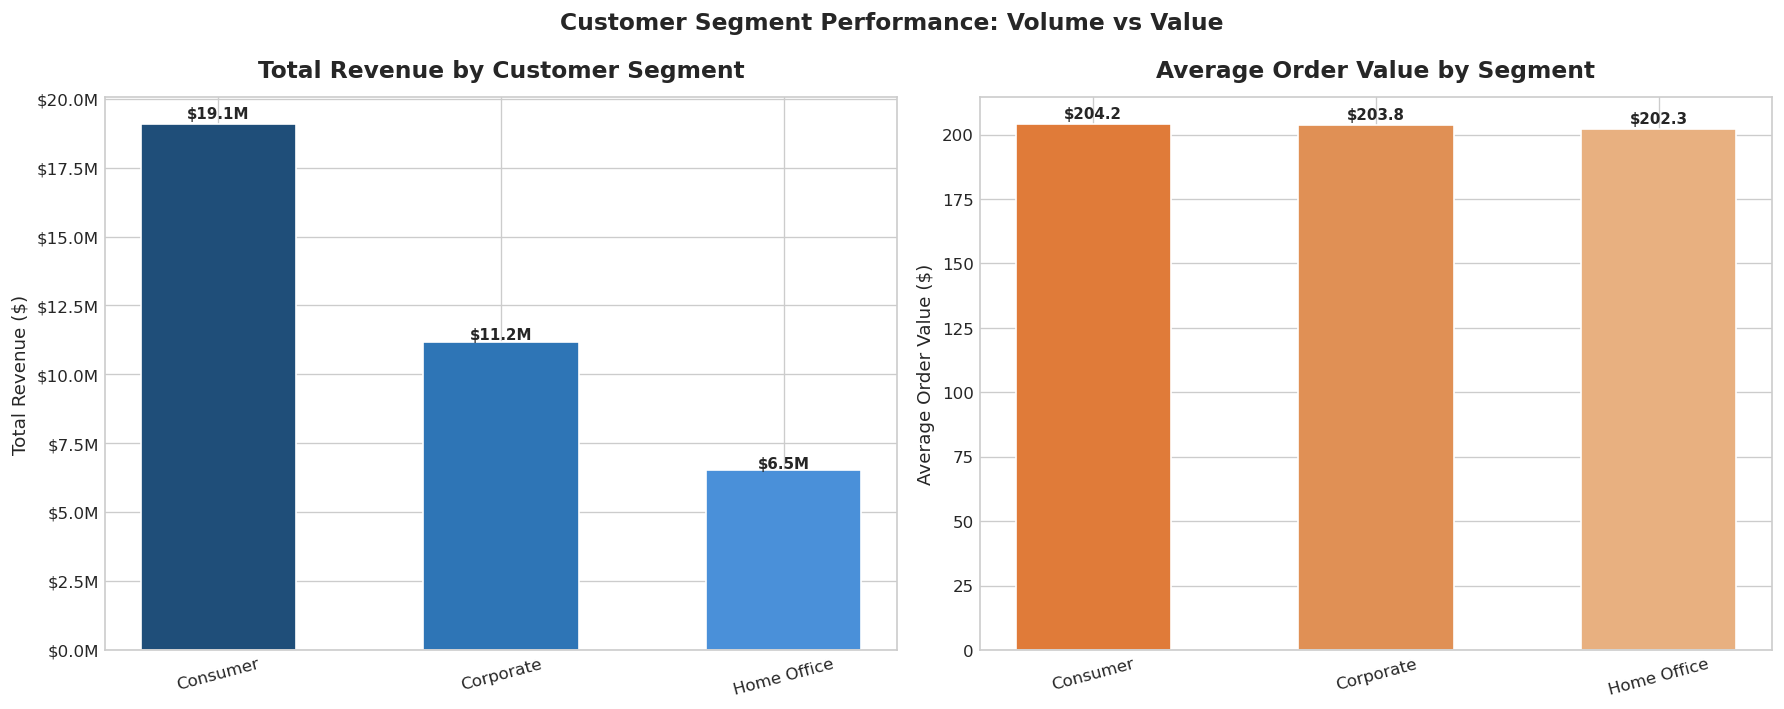

Segment Summary:
                  total_revenue  avg_order_value  total_profit  order_count
customer_segment                                                           
Consumer           1.909579e+07       204.224313  2.073488e+06        93504
Corporate          1.116841e+07       203.843962  1.202575e+06        54789
Home Office        6.520538e+06       202.337802  6.908403e+05        32226


In [212]:
seg_data = (
    df.groupby('customer_segment')
    .agg(
        total_revenue   = ('sales', 'sum'),
        avg_order_value = ('sales', 'mean'),
        total_profit    = ('order_profit_per_order', 'sum'),
        order_count     = ('order_id', 'count')
    )
    .sort_values('total_revenue', ascending=False)
)
 
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
 
# ---- Left: Total revenue ----
bars1 = axes[0].bar(seg_data.index, seg_data['total_revenue'],
                    color=BLUE_PALETTE[:len(seg_data)],
                    edgecolor='white', width=0.55)
for bar in bars1:
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, h * 1.01,
                 f'${h/1e6:.1f}M', ha='center', fontsize=9, fontweight='bold')
axes[0].set_title('Total Revenue by Customer Segment', pad=12)
axes[0].set_ylabel('Total Revenue ($)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))
axes[0].tick_params(axis='x', rotation=15)
 
# ---- Right: Average order value ----
bars2 = axes[1].bar(seg_data.index, seg_data['avg_order_value'],
                    color=[ACCENT_ORANGE, '#E09055', '#E8B080'][:len(seg_data)],
                    edgecolor='white', width=0.55)
for bar in bars2:
    h = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, h * 1.01,
                 f'${h:.1f}', ha='center', fontsize=9, fontweight='bold')
axes[1].set_title('Average Order Value by Segment', pad=12)
axes[1].set_ylabel('Average Order Value ($)')
axes[1].tick_params(axis='x', rotation=15)
 
plt.suptitle('Customer Segment Performance: Volume vs Value', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
 
print('Segment Summary:')
print(seg_data[['total_revenue','avg_order_value','total_profit','order_count']].to_string())


From the chart:
Consumer segment generates the highest total revenue.
Corporate customers contribute moderate revenue.
Home Office customers generate the lowest revenue.
The business relies primarily on Consumer customers for sales growth and revenue generation.
Consumer customers represent the largest customer base and purchase volume, making them the primary revenue engine.


Consumer customers have one of the highest average order values.
corporate Office customers also maintain a relatively high order value.
Home customers have a slightly lower average order value despite generating the highest total revenue.

Consumer revenue is driven by volume of orders.
Corporate revenue is driven by larger transaction sizes.
Home Office customers place fewer orders, resulting in lower overall revenue despite reasonable order values.   

**CHART 05:  Delivery Status Distribution + Late Rate by Market
Answers:  What percentage of all orders are late? Which global markets have the worst delivery performance?**


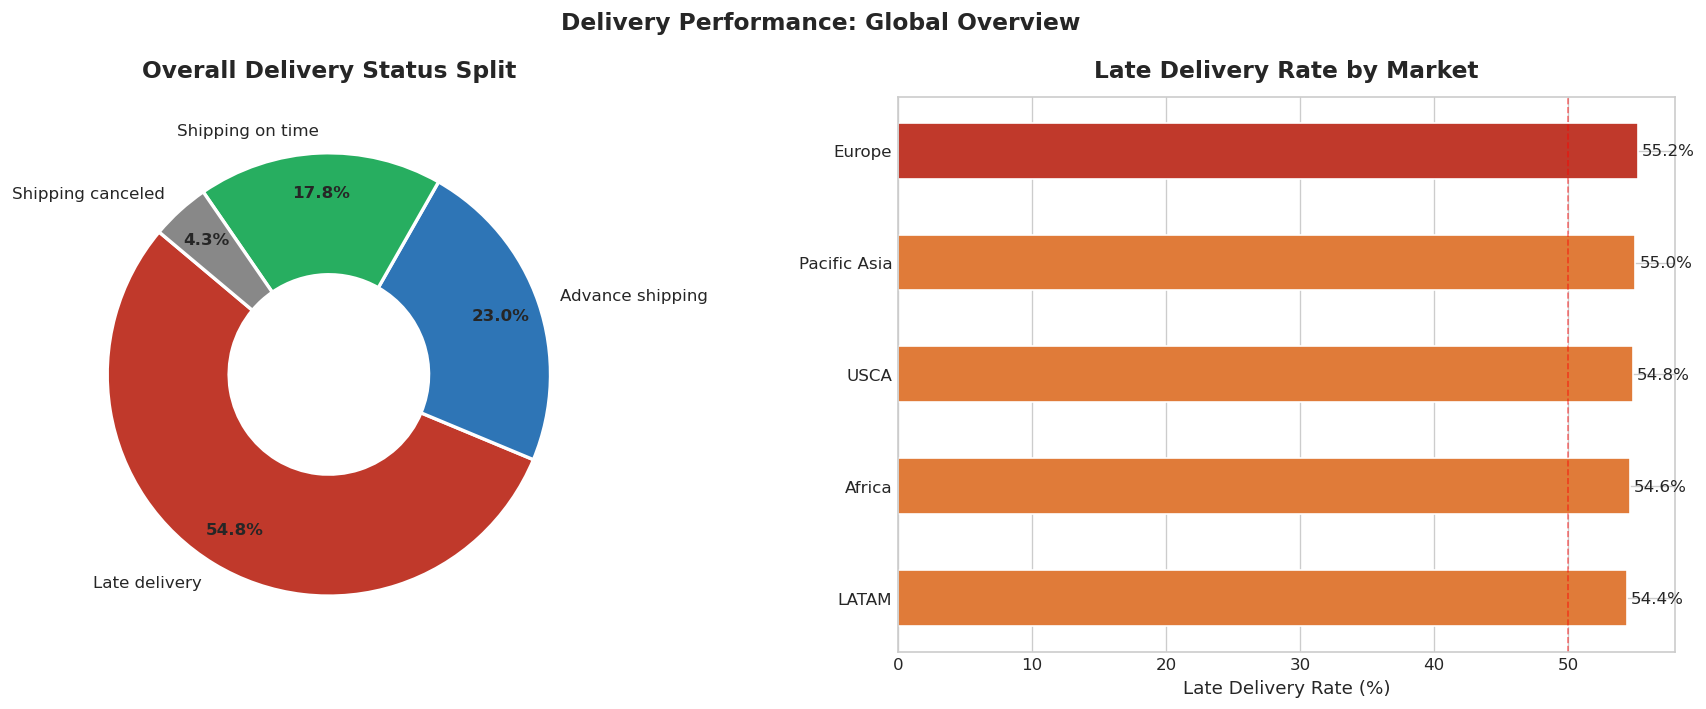

In [269]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
 
# ---- Left: Donut chart of delivery status ----
status_counts = df['delivery_status'].value_counts()
status_colors = {
    'Late delivery'       : DANGER_RED,
    'Shipping on time'    : SUCCESS_GREEN,
    'Shipping canceled'   : '#888888',
    'Advance shipping'    : '#2E75B6',
}
pie_colors = [status_colors.get(s, '#AAAAAA') for s in status_counts.index]
 
wedges, texts, autotexts = axes[0].pie(
    status_counts.values,
    labels=status_counts.index,
    autopct='%1.1f%%',
    colors=pie_colors,
    startangle=140,
    pctdistance=0.82,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2)  # donut style
)
for at in autotexts:
    at.set_fontsize(10)
    at.set_fontweight('bold')
axes[0].set_title('Overall Delivery Status Split', pad=12)
 
# ---- Right: Late rate by market ----
market_late = (
    df.groupby('market')
    .agg(total=('order_id','count'), late=('is_late_delivery','sum'))
    .assign(late_pct=lambda x: (x.late/x.total*100).round(1))
    .sort_values('late_pct', ascending=True)
)
bar_colors = [DANGER_RED if v > 55 else ACCENT_ORANGE if v > 45 else SUCCESS_GREEN
              for v in market_late['late_pct']]
bars = axes[1].barh(market_late.index, market_late['late_pct'],
                    color=bar_colors, edgecolor='white', height=0.5)
for bar in bars:
    w = bar.get_width()
    axes[1].text(w+0.3, bar.get_y()+bar.get_height()/2,
                 f'{w:.1f}%', va='center', fontsize=10)
axes[1].set_title('Late Delivery Rate by Market', pad=12)
axes[1].set_xlabel('Late Delivery Rate (%)')
axes[1].axvline(x=50, color='red', linestyle='--', alpha=0.5, linewidth=1)
 
plt.suptitle('Delivery Performance: Global Overview', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


More than half of all orders (54.8%) are delivered late, making late delivery the dominant fulfillment outcome.
Only 17.8% of shipments arrive exactly on time, indicating significant room for operational improvement.
About 23% of orders arrive earlier than promised, suggesting inconsistencies in delivery planning and estimated delivery dates.
Cancellation rate remains relatively low at 4.3%, indicating that customers generally complete purchases despite fulfillment issues.


The analysis revealed that 54.8% of all orders were delivered late, making late delivery the most common fulfillment outcome. Furthermore, delay rates remained consistently high across Europe, Pacific Asia, USCA, Africa, and LATAM (54–55%), indicating that the problem is not market-specific but a global operational issue. This suggests inefficiencies in order processing, inventory allocation, carrier management, or delivery promise estimation that affect the entire supply chain network.

**Discount Rate vs Profit Margin**

:  Does offering higher discounts damage profit margins? At what discount level do we lose money?

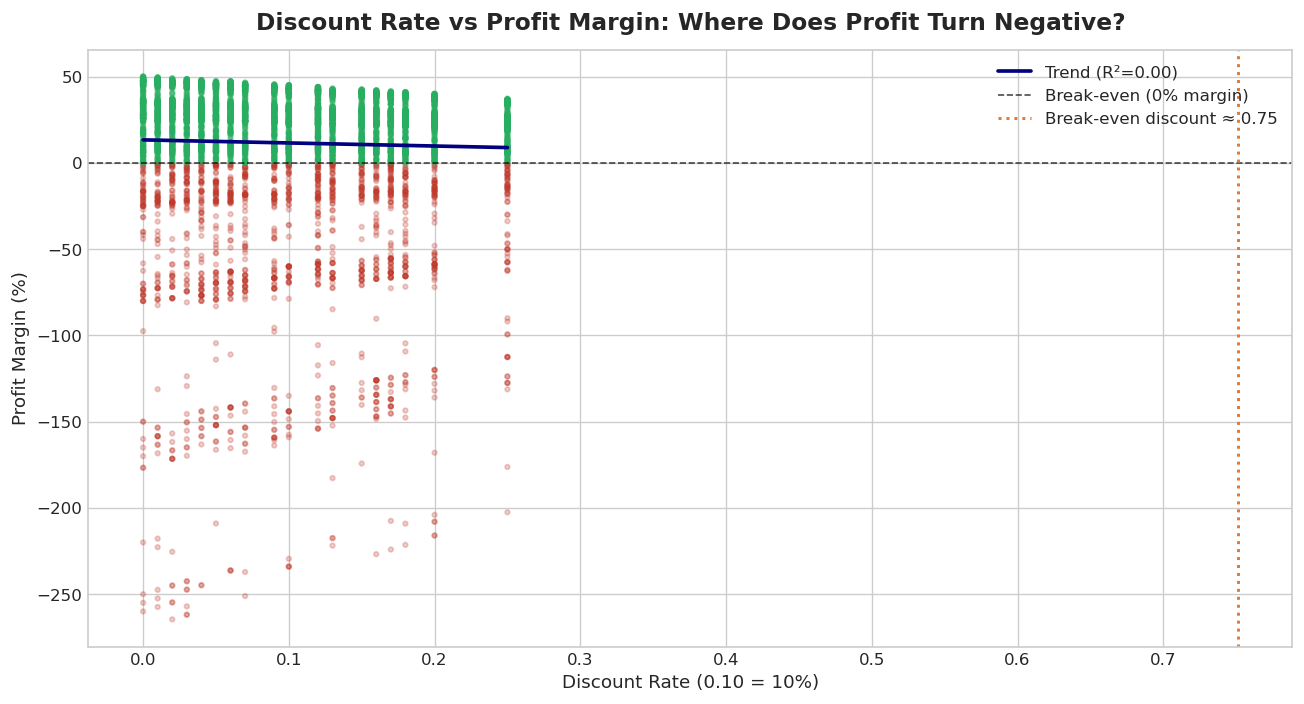

Pearson correlation: -0.031
Regression slope:    -17.83
Interpretation: Each 1-unit increase in discount rate changes margin by -17.83%


In [271]:
# Sample for readability - 8000 points is enough to show the pattern
sample = df[['order_item_discount_rate','profit_margin_pct']].dropna().sample(
    min(8000, len(df)), random_state=42)
 
fig, ax = plt.subplots(figsize=(11, 6))
 
# Scatter points coloured by profit zone
colors_sc = ['#C0392B' if p < 0 else '#27AE60' for p in sample['profit_margin_pct']]
ax.scatter(sample['order_item_discount_rate'],
           sample['profit_margin_pct'],
           c=colors_sc, alpha=0.25, s=8, rasterized=True)
 
# Add OLS regression line to show overall trend
x_vals = sample['order_item_discount_rate'].values
y_vals = sample['profit_margin_pct'].values
slope, intercept, r_val, p_val, _ = stats.linregress(x_vals, y_vals)
x_line = np.linspace(x_vals.min(), x_vals.max(), 100)
ax.plot(x_line, slope * x_line + intercept,
        color='navy', linewidth=2.2, label=f'Trend (R²={r_val**2:.2f})')
 
# Break-even reference line
ax.axhline(y=0, color='black', linewidth=1.0, linestyle='--', alpha=0.7,
           label='Break-even (0% margin)')
 
# Find break-even discount rate
if slope != 0:
    breakeven_discount = -intercept / slope
    ax.axvline(x=breakeven_discount, color=ACCENT_ORANGE, linestyle=':',
               linewidth=1.8, label=f'Break-even discount ≈ {breakeven_discount:.2f}')
 
ax.set_title('Discount Rate vs Profit Margin: Where Does Profit Turn Negative?', pad=12)
ax.set_xlabel('Discount Rate (0.10 = 10%)')
ax.set_ylabel('Profit Margin (%)')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()
 
corr = sample['order_item_discount_rate'].corr(sample['profit_margin_pct'])
print(f'Pearson correlation: {corr:.3f}')
print(f'Regression slope:    {slope:.2f}')
print(f'Interpretation: Each 1-unit increase in discount rate changes margin by {slope:.2f}%')


The chart shows that while higher discounts increase the likelihood of negative margins, losses are also occurring at lower discount levels.

This suggests that discount alone is not the primary driver of profitability. Other factors such as cost structure, product category, and logistics may be influencing margins.

Therefore, instead of applying blanket discounts, the business should adopt a more targeted pricing strategy based on product profitability.